In [47]:
import requests
import os
from urllib.parse import urlparse
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import json
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
import numpy as np
from sklearn.metrics import mean_squared_error
import optuna

## Fetchin the data


In [48]:
def download_file(url, save_path=None):
    try:
        response = requests.get(url, stream=True, timeout=15)
        response.raise_for_status()

        if save_path is None:
            filename = os.path.basename(urlparse(url).path) or "downloaded_file"
            save_path = os.path.join(os.getcwd(), filename)

        total_size = int(response.headers.get('content-length', 0))
        block_size = 1024

        downloaded_size = 0
        with open(save_path, 'wb') as file:
            for data in response.iter_content(block_size):
                file.write(data)
                downloaded_size += len(data)
                if total_size:
                    percent = (downloaded_size / total_size) * 100
                    print(f"\rDownloading: {percent:.2f}%", end="")

        print(f"\nDownload complete: {save_path}")

    except requests.exceptions.MissingSchema:
        print("Invalid URL format.")
    except requests.exceptions.ConnectionError:
        print("Connection error. Check your internet connection.")
    except requests.exceptions.Timeout:
        print("Request timed out.")
    except requests.exceptions.HTTPError as e:
        print(f"HTTP error: {e}")
    except Exception as e:
        print(f"An unexpected error occurred: {e}")


In [49]:
BASE_URL = 'https://raw.githubusercontent.com/jcpeterson/choices13k/refs/heads/main'

csv_url = f'{BASE_URL}/c13k_selections.csv'
json_url = f'{BASE_URL}/c13k_problems.json'

if not os.path.exists('c13k_selections.csv'):
    download_file(csv_url)
if not os.path.exists('c13k_problems.json'):
    download_file(json_url)

In [50]:
def validate_json_file(path: str) -> bool:
    try:
        with open(path, "r", encoding="utf-8") as f:
            json.load(f)
        print("JSON is valid")
        return True
    except json.JSONDecodeError as e:
        print("Invalid JSON:", e)
        return False

validate_json_file("c13k_problems.json")


JSON is valid


True

In [51]:
df = pd.read_csv('c13k_selections.csv')
df.head()
df.isnull().sum()

Problem      0
Feedback     0
n            0
Block        0
Ha           0
pHa          0
La           0
Hb           0
pHb          0
Lb           0
LotShapeB    0
LotNumB      0
Amb          0
Corr         0
bRate        0
bRate_std    0
dtype: int64

In [52]:
len(df)

14568

In [53]:
problems = pd.read_json("c13k_problems.json", orient='index')
problems

,B,A
0,"[[0.9500000000000001, 21.0], [0.05, 23.0]]","[[0.9500000000000001, 26.0], [0.05, -1.0]]"
1,"[[0.75, -5.0], [0.25, 8.0]]","[[0.6000000000000001, 14.0], [0.4, -18.0]]"
2,"[[1.0, 1.0]]","[[0.5, 2.0], [0.5, 0.0]]"
3,"[[0.75, -31.0], [0.125, 86.5], [0.125, 87.5]]","[[0.05, 37.0], [0.9500000000000001, 8.0]]"
4,"[[0.25, -36.0], [0.375, 41.0], [0.1875, 43.0],...","[[1.0, 26.0], [0.0, 26.0]]"
...,...,...
14563,"[[0.199999999999999, 0.0], [0.8, 42.0]]","[[1.0, 30.0], [0.0, 30.0]]"
14564,"[[0.199999999999999, 7.0], [0.8, 18.0]]","[[0.5, 70.0], [0.5, -42.0]]"
14565,"[[0.6000000000000001, -34.0], [0.0125, 28.5], ...","[[0.4, 8.0], [0.6000000000000001, -17.0]]"
14566,"[[0.5, -12.0], [0.5, 45.0]]","[[0.5, 89.0], [0.5, -49.0]]"


In [54]:
selections = pd.read_csv('c13k_selections.csv')

with pd.option_context('display.max_columns', None):
    display(selections)

,Problem,Feedback,n,Block,Ha,pHa,La,Hb,pHb,Lb,LotShapeB,LotNumB,Amb,Corr,bRate,bRate_std
0,1,True,15,2,26,0.95,-1,23,0.05,21,0,1,False,0,0.626667,0.384460
1,2,True,15,4,14,0.60,-18,8,0.25,-5,0,1,True,-1,0.493333,0.413118
2,3,True,17,4,2,0.50,0,1,1.00,1,0,1,False,0,0.611765,0.432843
3,4,True,18,3,37,0.05,8,87,0.25,-31,1,2,False,0,0.222222,0.387383
4,5,False,15,1,26,1.00,26,45,0.75,-36,2,5,False,0,0.586667,0.450185
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14563,13002,True,15,3,30,1.00,30,42,0.80,0,0,1,True,0,0.367619,0.302731
14564,13003,True,15,5,70,0.50,-42,18,0.80,7,0,1,False,0,0.760000,0.364104
14565,13004,True,15,5,8,0.40,-17,31,0.40,-34,1,6,False,0,0.666667,0.367747
14566,13005,True,15,2,89,0.50,-49,45,0.50,-12,0,1,False,0,0.386667,0.381476


In [55]:
selections.columns = [col.lower() for col in selections.columns]

In [56]:
df_full = selections.join(problems, how='left')

In [57]:
with pd.option_context('display.max_columns', None):
    display(df_full)

,problem,feedback,n,block,ha,pha,la,hb,phb,lb,lotshapeb,lotnumb,amb,corr,brate,brate_std,B,A
0,1,True,15,2,26,0.95,-1,23,0.05,21,0,1,False,0,0.626667,0.384460,"[[0.9500000000000001, 21.0], [0.05, 23.0]]","[[0.9500000000000001, 26.0], [0.05, -1.0]]"
1,2,True,15,4,14,0.60,-18,8,0.25,-5,0,1,True,-1,0.493333,0.413118,"[[0.75, -5.0], [0.25, 8.0]]","[[0.6000000000000001, 14.0], [0.4, -18.0]]"
2,3,True,17,4,2,0.50,0,1,1.00,1,0,1,False,0,0.611765,0.432843,"[[1.0, 1.0]]","[[0.5, 2.0], [0.5, 0.0]]"
3,4,True,18,3,37,0.05,8,87,0.25,-31,1,2,False,0,0.222222,0.387383,"[[0.75, -31.0], [0.125, 86.5], [0.125, 87.5]]","[[0.05, 37.0], [0.9500000000000001, 8.0]]"
4,5,False,15,1,26,1.00,26,45,0.75,-36,2,5,False,0,0.586667,0.450185,"[[0.25, -36.0], [0.375, 41.0], [0.1875, 43.0],...","[[1.0, 26.0], [0.0, 26.0]]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14563,13002,True,15,3,30,1.00,30,42,0.80,0,0,1,True,0,0.367619,0.302731,"[[0.199999999999999, 0.0], [0.8, 42.0]]","[[1.0, 30.0], [0.0, 30.0]]"
14564,13003,True,15,5,70,0.50,-42,18,0.80,7,0,1,False,0,0.760000,0.364104,"[[0.199999999999999, 7.0], [0.8, 18.0]]","[[0.5, 70.0], [0.5, -42.0]]"
14565,13004,True,15,5,8,0.40,-17,31,0.40,-34,1,6,False,0,0.666667,0.367747,"[[0.6000000000000001, -34.0], [0.0125, 28.5], ...","[[0.4, 8.0], [0.6000000000000001, -17.0]]"
14566,13005,True,15,2,89,0.50,-49,45,0.50,-12,0,1,False,0,0.386667,0.381476,"[[0.5, -12.0], [0.5, 45.0]]","[[0.5, 89.0], [0.5, -49.0]]"


# Investigate duplicate values

In [58]:
counts = df_full.groupby('problem').size().reset_index(name='count').sort_values(by="count", ascending=False)

In [59]:
idx = counts.loc[counts["count"] > 1, "problem"].tolist()


In [60]:
df_full.loc[df_full['problem'].isin(idx),:]

,problem,feedback,n,block,ha,pha,la,hb,phb,lb,lotshapeb,lotnumb,amb,corr,brate,brate_std,B,A
6,7,False,15,1,-6,1.00,-6,24,0.20,-5,1,2,False,0,0.866667,0.351866,"[[0.8, -5.0], [0.1, 23.5], [0.1, 24.5]]","[[1.0, -6.0], [0.0, -6.0]]"
7,7,True,16,3,-6,1.00,-6,24,0.20,-5,1,2,False,0,0.962500,0.150000,"[[0.8, -5.0], [0.1, 23.5], [0.1, 24.5]]","[[1.0, -6.0], [0.0, -6.0]]"
8,8,False,15,1,27,1.00,27,89,0.50,-24,0,1,False,0,0.453333,0.403320,"[[0.5, -24.0], [0.5, 89.0]]","[[1.0, 27.0], [0.0, 27.0]]"
9,8,True,16,2,27,1.00,27,89,0.50,-24,0,1,False,0,0.612500,0.434933,"[[0.5, -24.0], [0.5, 89.0]]","[[1.0, 27.0], [0.0, 27.0]]"
11,10,False,15,1,1,1.00,1,59,0.05,0,0,1,True,0,0.773333,0.406143,"[[0.9500000000000001, 0.0], [0.05, 59.0]]","[[1.0, 1.0], [0.0, 1.0]]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8293,6734,True,18,5,77,0.01,30,116,0.40,-12,2,5,True,0,0.688889,0.292834,"[[0.6000000000000001, -12.0], [0.2, 112.0], [0...","[[0.01, 77.0], [0.99, 30.0]]"
8296,6737,False,16,1,26,1.00,26,41,0.60,7,0,1,False,0,0.450000,0.287518,"[[0.4, 7.0], [0.6000000000000001, 41.0]]","[[1.0, 26.0], [0.0, 26.0]]"
8297,6737,True,16,3,26,1.00,26,41,0.60,7,0,1,False,0,0.600000,0.309839,"[[0.4, 7.0], [0.6000000000000001, 41.0]]","[[1.0, 26.0], [0.0, 26.0]]"
8299,6739,False,16,1,-1,0.95,-4,10,0.75,-17,2,3,False,0,0.787500,0.247319,"[[0.25, -17.0], [0.375, 8.0], [0.1875, 10.0], ...","[[0.9500000000000001, -1.0], [0.05, -4.0]]"


In [61]:
df_full['feedback'].value_counts()

feedback
True     12188
False     2380
Name: count, dtype: int64

In [62]:
count = (
    df_full
    .groupby("problem")["feedback"]
    .nunique()
    .eq(2)
    .sum()
)

print(count)


1562


## Investigating the data

First 5 rows of df:


,problem,feedback,n,block,ha,pha,la,hb,phb,lb,lotshapeb,lotnumb,amb,corr,brate,brate_std,B,A
0,1,True,15,2,26,0.95,-1,23,0.05,21,0,1,False,0,0.626667,0.384460,"[[0.9500000000000001, 21.0], [0.05, 23.0]]","[[0.9500000000000001, 26.0], [0.05, -1.0]]"
1,2,True,15,4,14,0.60,-18,8,0.25,-5,0,1,True,-1,0.493333,0.413118,"[[0.75, -5.0], [0.25, 8.0]]","[[0.6000000000000001, 14.0], [0.4, -18.0]]"
2,3,True,17,4,2,0.50,0,1,1.00,1,0,1,False,0,0.611765,0.432843,"[[1.0, 1.0]]","[[0.5, 2.0], [0.5, 0.0]]"
3,4,True,18,3,37,0.05,8,87,0.25,-31,1,2,False,0,0.222222,0.387383,"[[0.75, -31.0], [0.125, 86.5], [0.125, 87.5]]","[[0.05, 37.0], [0.9500000000000001, 8.0]]"
4,5,False,15,1,26,1.00,26,45,0.75,-36,2,5,False,0,0.586667,0.450185,"[[0.25, -36.0], [0.375, 41.0], [0.1875, 43.0],...","[[1.0, 26.0], [0.0, 26.0]]"



Summary statistics:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
problem,14568.0,NaN,NaN,NaN,6163.333677,3733.123605,1.0,2961.75,5888.5,9364.25,13006.0
feedback,14568,2,True,12188,NaN,NaN,NaN,NaN,NaN,NaN,NaN
n,14568.0,NaN,NaN,NaN,16.670717,2.588231,15.0,16.0,16.0,17.0,33.0
block,14568.0,NaN,NaN,NaN,3.099053,1.379569,1.0,2.0,3.0,4.0,5.0
ha,14568.0,NaN,NaN,NaN,22.014072,24.076396,-10.0,5.0,18.0,29.0,118.0
pha,14568.0,NaN,NaN,NaN,0.747192,0.351998,0.01,0.5,1.0,1.0,1.0
la,14568.0,NaN,NaN,NaN,3.813152,16.406765,-50.0,-6.0,5.0,17.0,30.0
hb,14568.0,NaN,NaN,NaN,35.583677,27.659754,-18.0,15.0,30.0,52.0,119.0
phb,14568.0,NaN,NaN,NaN,0.444946,0.325977,0.01,0.2,0.4,0.75,1.0
lb,14568.0,NaN,NaN,NaN,-4.147721,18.270573,-50.0,-16.0,-3.0,9.0,41.0



Missing values per column:
problem      0
feedback     0
n            0
block        0
ha           0
pha          0
la           0
hb           0
phb          0
lb           0
lotshapeb    0
lotnumb      0
amb          0
corr         0
brate        0
brate_std    0
B            0
A            0
dtype: int64


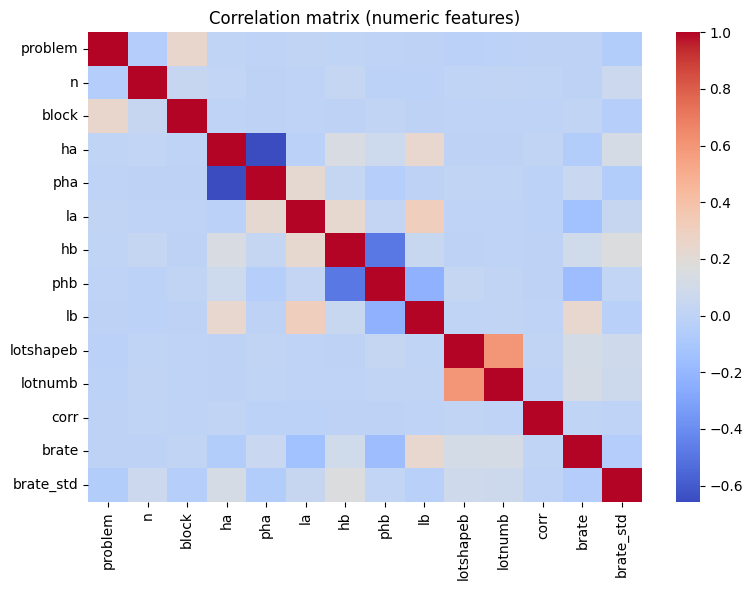

In [63]:
# Basic exploration of the dataset

from IPython.display import display
print("First 5 rows of df:")
display(df_full.head())

# Summary statistics (numeric and categorical)
print("\nSummary statistics:")
display(df_full.describe(include="all").T)

# Missing values per column
print("\nMissing values per column:")
print(df_full.isnull().sum())

# Distribution of the main rate column (if present)
if "bRate" in df_full.columns:
    plt.figure(figsize=(6, 4))
    sns.histplot(df_full["bRate"], kde=True)
    plt.title("Distribution of bRate")
    plt.xlabel("bRate")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

# Correlation matrix for numeric features
numeric_df = df_full.select_dtypes(include=["number"])
if not numeric_df.empty:
    plt.figure(figsize=(8, 6))
    corr = numeric_df.corr()
    sns.heatmap(corr, annot=False, cmap="coolwarm", fmt=".2f")
    plt.title("Correlation matrix (numeric features)")
    plt.tight_layout()
    plt.show()

Correlation of each numeric feature with brate (sorted):


,corr_with_bRate
lb,0.238497
lotnumb,0.122896
lotshapeb,0.112797
hb,0.092437
amb,0.087488
pha,0.053659
block,0.015038
corr,0.005025
feedback,0.003050
problem,-0.005596


C:\Users\anast\AppData\Local\Temp\ipykernel_27860\2802929659.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=corr_with_brate.values, y=corr_with_brate.index, palette="viridis")


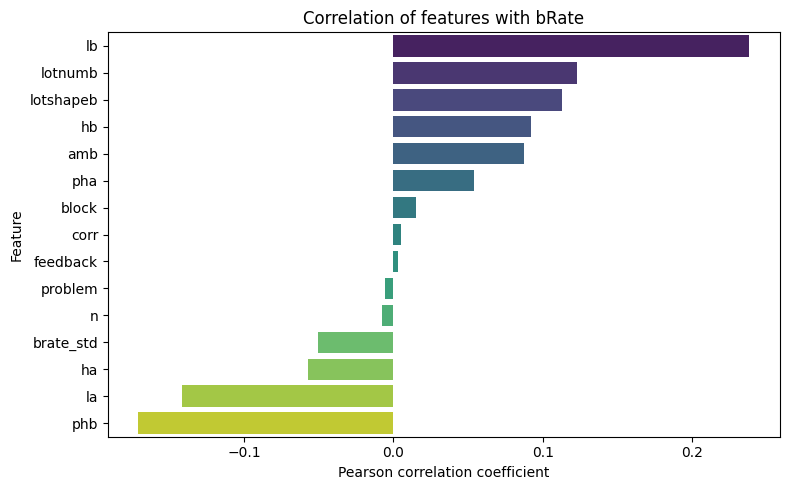

In [64]:
# Correlation of all numeric features with bRate

corr_matrix = df_full.corr(numeric_only=True)
corr_with_brate = corr_matrix["brate"].drop(labels=["brate"], errors="ignore").sort_values(ascending=False)

print("Correlation of each numeric feature with brate (sorted):")
display(corr_with_brate.to_frame(name="corr_with_bRate"))

# Bar plot of correlations
plt.figure(figsize=(8, 5))
sns.barplot(x=corr_with_brate.values, y=corr_with_brate.index, palette="viridis")
plt.title("Correlation of features with bRate")
plt.xlabel("Pearson correlation coefficient")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## Feature Engineering

In [65]:
# Step 1: Basic numeric cleaning (round all numeric columns)

numeric_cols = df_full.select_dtypes(include=[np.number]).columns

for col in numeric_cols:
    # Keep 'problem' as an identifier, don't round it
    if col != "problem":
        df_full[col] = df_full[col].round(2)

In [66]:
# Step 2: Helper functions for gamble lists and basic EV/std features

import ast
import numpy as np

def _ensure_gamble_list(gamble_list):
    """Ensure we always work with a list[(p, r)], not a JSON string."""
    if isinstance(gamble_list, str):
        return ast.literal_eval(gamble_list)
    return gamble_list

def round_gamble_column(gamble_list, decimals=2):
    """Round probabilities and rewards to a fixed number of decimals."""
    gl = _ensure_gamble_list(gamble_list)
    return [(round(p, decimals), round(r, decimals)) for p, r in gl]

def calculate_gamble_stats(gamble_list):
    """
    Compute expected value (EV) and standard deviation for a gamble.

    gamble_list: list of (probability, reward) tuples
    returns: (ev, std_dev)
    """
    gl = _ensure_gamble_list(gamble_list)
    probs = [x[0] for x in gl]
    rewards = [x[1] for x in gl]

    ev = sum(p * r for p, r in zip(probs, rewards))
    variance = sum(p * (r - ev) ** 2 for p, r in zip(probs, rewards))
    std_dev = np.sqrt(variance)

    return round(ev, 2), round(std_dev, 2)

# Apply rounding to raw gamble columns
df_full["A"] = df_full["A"].apply(round_gamble_column)
df_full["B"] = df_full["B"].apply(round_gamble_column)

# Compute EV and std for each option
df_full["A_ev"], df_full["A_std"] = zip(*df_full["A"].apply(calculate_gamble_stats))
df_full["B_ev"], df_full["B_std"] = zip(*df_full["B"].apply(calculate_gamble_stats))

# Basic risk features
df_full["std_diff"] = df_full["A_std"] - df_full["B_std"]
df_full["variance_diff"] = df_full["A_std"] ** 2 - df_full["B_std"] ** 2

In [67]:
# Step 3: Extreme outcome flags and worst-outcome features

def has_extreme_outcomes(gamble_list, loss_threshold=-20, gain_threshold=50):
    """
    Check if a gamble has extreme outcomes (large losses or gains).

    returns: (has_large_loss, has_large_gain)
    """
    gl = _ensure_gamble_list(gamble_list)
    rewards = [x[1] for x in gl]
    has_large_loss = any(r <= loss_threshold for r in rewards)
    has_large_gain = any(r >= gain_threshold for r in rewards)
    return has_large_loss, has_large_gain

# Extreme outcome indicators for A and B
df_full["A_has_large_loss"], df_full["A_has_large_gain"] = zip(
    *df_full["A"].apply(lambda x: has_extreme_outcomes(x, loss_threshold=-20, gain_threshold=50))
)
df_full["B_has_large_loss"], df_full["B_has_large_gain"] = zip(
    *df_full["B"].apply(lambda x: has_extreme_outcomes(x, loss_threshold=-20, gain_threshold=50))
)

# EV difference
df_full["ev_diff"] = df_full["A_ev"] - df_full["B_ev"]

def get_min_outcome(gamble_list):
    """Get the minimum (worst) outcome from a gamble."""
    gl = _ensure_gamble_list(gamble_list)
    rewards = [x[1] for x in gl]
    return min(rewards)

# Worst outcomes and their difference
df_full["A_min"] = df_full["A"].apply(get_min_outcome)
df_full["B_min"] = df_full["B"].apply(get_min_outcome)
df_full["min_diff"] = df_full["A_min"] - df_full["B_min"]

In [68]:
# Step 4: Positive payoff probabilities

def prob_positive(gamble_list):
    """Calculate probability of getting a strictly positive payoff."""
    gl = _ensure_gamble_list(gamble_list)
    return sum(p for p, r in gl if r > 0)

df_full["A_prob_positive"] = df_full["A"].apply(prob_positive)
df_full["B_prob_positive"] = df_full["B"].apply(prob_positive)
df_full["prob_positive_diff"] = (
    df_full["A_prob_positive"] - df_full["B_prob_positive"]
)

In [69]:
# Step 5: BEAST-style psychological features (P(A>B), regret, worst-case, etc.)

def prob_A_beats_B(gamble_A, gamble_B):
    """
    P(X_A > X_B) in a single draw by convolving the two distributions.
    """
    gA = _ensure_gamble_list(gamble_A)
    gB = _ensure_gamble_list(gamble_B)

    prob_A_beats = 0.0
    for p_A, r_A in gA:
        for p_B, r_B in gB:
            if r_A > r_B:
                prob_A_beats += p_A * p_B
    return prob_A_beats

df_full["prob_A_beats_B"] = df_full.apply(
    lambda row: prob_A_beats_B(row["A"], row["B"]), axis=1
)

def expected_regret(gamble_A, gamble_B):
    """
    Expected regret if choosing A: E[max(0, X_B - X_A)].
    """
    gA = _ensure_gamble_list(gamble_A)
    gB = _ensure_gamble_list(gamble_B)

    expected_regret_val = 0.0
    for p_A, r_A in gA:
        for p_B, r_B in gB:
            regret = max(0, r_B - r_A)
            expected_regret_val += p_A * p_B * regret
    return expected_regret_val

df_full["expected_regret"] = df_full.apply(
    lambda row: expected_regret(row["A"], row["B"]), axis=1
)

def prob_regret(gamble_A, gamble_B):
    """
    Probability of regret: P(X_B > X_A).
    """
    gA = _ensure_gamble_list(gamble_A)
    gB = _ensure_gamble_list(gamble_B)

    prob_regret_val = 0.0
    for p_A, r_A in gA:
        for p_B, r_B in gB:
            if r_B > r_A:
                prob_regret_val += p_A * p_B
    return prob_regret_val

df_full["prob_regret"] = df_full.apply(
    lambda row: prob_regret(row["A"], row["B"]), axis=1
)

def prob_worst_outcome(gamble_list):
    """
    Probability of hitting the worst (minimum) outcome.
    """
    gl = _ensure_gamble_list(gamble_list)
    rewards = [x[1] for x in gl]
    min_reward = min(rewards)
    return sum(p for p, r in gl if r == min_reward)

df_full["A_prob_worst"] = df_full["A"].apply(prob_worst_outcome)
df_full["B_prob_worst"] = df_full["B"].apply(prob_worst_outcome)
df_full["prob_worst_diff"] = df_full["A_prob_worst"] - df_full["B_prob_worst"]

# Quick sanity check: show first few engineered rows
df_full.head(10)

,problem,feedback,n,block,ha,pha,la,hb,phb,lb,...,min_diff,A_prob_positive,B_prob_positive,prob_positive_diff,prob_A_beats_B,expected_regret,prob_regret,A_prob_worst,B_prob_worst,prob_worst_diff
0,1,True,15,2,26,0.95,-1,23,0.05,21,...,-22.0,0.95,1.00,-0.05,0.95,1.105,0.05,0.05,0.95,-0.90
1,2,True,15,4,14,0.60,-18,8,0.25,-5,...,-13.0,0.60,0.25,0.35,0.60,6.500,0.40,0.40,0.75,-0.35
2,3,True,17,4,2,0.50,0,1,1.00,1,...,-1.0,0.50,1.00,-0.50,0.50,0.500,0.50,0.50,1.00,-0.50
3,4,True,18,3,37,0.05,8,87,0.25,-31,...,39.0,1.00,0.24,0.76,0.75,18.612,0.24,0.95,0.75,0.20
4,5,False,15,1,26,1.00,26,45,0.75,-36,...,62.0,1.00,0.76,0.24,0.25,14.520,0.76,1.00,0.25,0.75
5,6,True,15,4,28,1.00,28,33,0.01,28,...,0.0,1.00,1.00,0.00,0.00,0.030,0.01,1.00,0.99,0.01
6,7,False,15,1,-6,1.00,-6,24,0.20,-5,...,-1.0,0.00,0.20,-0.20,0.00,6.800,1.00,1.00,0.80,0.20
7,7,True,16,3,-6,1.00,-6,24,0.20,-5,...,-1.0,0.00,0.20,-0.20,0.00,6.800,1.00,1.00,0.80,0.20
8,8,False,15,1,27,1.00,27,89,0.50,-24,...,51.0,1.00,0.50,0.50,0.50,31.000,0.50,1.00,0.50,0.50
9,8,True,16,2,27,1.00,27,89,0.50,-24,...,51.0,1.00,0.50,0.50,0.50,31.000,0.50,1.00,0.50,0.50


# Modelling

In [ ]:

TARGET_COL = 'brate'
# Use only numeric/bool columns so StandardScaler and models get no list-valued columns (e.g. A, B)
X = df_full.drop(columns=[TARGET_COL]).select_dtypes(include=[np.number, "bool"])

In [72]:
X.columns

Index(['problem', 'feedback', 'n', 'block', 'ha', 'pha', 'la', 'hb', 'phb',
       'lb', 'lotshapeb', 'lotnumb', 'amb', 'corr', 'brate_std', 'A_ev',
       'A_std', 'B_ev', 'B_std', 'std_diff', 'variance_diff',
       'A_has_large_loss', 'A_has_large_gain', 'B_has_large_loss',
       'B_has_large_gain', 'ev_diff', 'A_min', 'B_min', 'min_diff',
       'A_prob_positive', 'B_prob_positive', 'prob_positive_diff',
       'prob_A_beats_B', 'expected_regret', 'prob_regret', 'A_prob_worst',
       'B_prob_worst', 'prob_worst_diff'],
      dtype='str')

In [73]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV


def run_experiment(
    model, X, y,
    params=None,
    search_engine="optuna",          # "optuna" | "random" | "grid" | None
    cv_folds=3,
    n_trials=50,                     # optuna trials
    n_iter=20,                       # randomized iterations
    verbose=1,
    sample_size=None,
    run_full_pipeline=True,
    scoring="neg_mean_absolute_error",
    random_state=42,
):
    """
    Run experiment with optional hyperparameter tuning using Optuna / RandomizedSearchCV / GridSearchCV.

    params:
      - if search_engine in {"grid","random"}: dict of lists (classic sklearn grid)
      - if search_engine == "optuna": dict describing search space (see examples below)
    """

    # Build pipeline (same as yours)
    if run_full_pipeline:
        num_cols = X.select_dtypes(include=[np.number, "bool"]).columns.tolist()

        pipeline = Pipeline(steps=[
            ("prep", ColumnTransformer(
                transformers=[
                    ("num", Pipeline(steps=[
                        ("imputer", SimpleImputer(strategy="median")),
                        ("scaler", StandardScaler()),
                    ]), num_cols),
                ],
                remainder="drop"
            )),
            ("reg", model)
        ])
        needs_prefix = True
    else:
        pipeline = model
        needs_prefix = False

    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=random_state
    )

    # Optional sampling for faster tuning
    if sample_size is not None and params is not None and search_engine in {"grid", "random", "optuna"}:
        if isinstance(sample_size, float):
            n_samples = int(len(X_train) * sample_size)
        else:
            n_samples = min(int(sample_size), len(X_train))
        rng = np.random.RandomState(random_state)
        sample_idx = rng.choice(len(X_train), n_samples, replace=False)
        X_train_sample = X_train.iloc[sample_idx] if hasattr(X_train, "iloc") else X_train[sample_idx]
        y_train_sample = y_train.iloc[sample_idx] if hasattr(y_train, "iloc") else y_train[sample_idx]
        if verbose:
            print(f"Using {n_samples}/{len(X_train)} samples for tuning...")
    else:
        X_train_sample, y_train_sample = X_train, y_train

    best_params = None
    best_estimator = None

    # -------------------------
    # Hyperparameter Tuning
    # -------------------------
    if params is not None and search_engine is not None:
        if search_engine in {"grid", "random"}:
            # sklearn-style lists
            param_grid = {f"reg__{k}": v for k, v in params.items()} if needs_prefix else params

            if search_engine == "random":
                search = RandomizedSearchCV(
                    estimator=pipeline,
                    param_distributions=param_grid,
                    n_iter=n_iter,
                    cv=cv_folds,
                    scoring=scoring,
                    n_jobs=-1,
                    random_state=random_state,
                    verbose=verbose
                )
                if verbose:
                    print(f"Running RandomizedSearchCV with {n_iter} iterations, {cv_folds}-fold CV...")
            else:
                search = GridSearchCV(
                    estimator=pipeline,
                    param_grid=param_grid,
                    cv=cv_folds,
                    scoring=scoring,
                    n_jobs=-1,
                    verbose=verbose
                )
                if verbose:
                    total_combinations = 1
                    for v in param_grid.values():
                        total_combinations *= len(v)
                    print(f"Running GridSearchCV with {total_combinations} combinations, {cv_folds}-fold CV...")

            search.fit(X_train_sample, y_train_sample)

            best_params = search.best_params_
            if verbose:
                print("Best parameters:", best_params)
                print("Best CV score (MAE):", -search.best_score_)

            # If sampled, refit on full training set
            if sample_size is not None:
                if verbose:
                    print("Refitting best model on full training data...")
                pipeline.set_params(**best_params)
                pipeline.fit(X_train, y_train)
                best_estimator = pipeline
            else:
                best_estimator = search.best_estimator_

        elif search_engine == "optuna":
            # Optuna search space spec (see examples below)
            def suggest_params(trial):
                suggested = {}
                for name, spec in params.items():
                    # Support a few spec patterns:
                    # 1) ("categorical", [...])
                    # 2) ("int", low, high, log=False, step=1)
                    # 3) ("float", low, high, log=False, step=None)
                    kind = spec[0].lower()

                    if kind == "categorical":
                        suggested[name] = trial.suggest_categorical(name, spec[1])

                    elif kind == "int":
                        low, high = int(spec[1]), int(spec[2])
                        log = bool(spec[3]) if len(spec) > 3 else False
                        step = int(spec[4]) if len(spec) > 4 and spec[4] is not None else 1
                        suggested[name] = trial.suggest_int(name, low, high, log=log, step=step)

                    elif kind == "float":
                        low, high = float(spec[1]), float(spec[2])
                        log = bool(spec[3]) if len(spec) > 3 else False
                        step = spec[4] if len(spec) > 4 else None
                        if step is None:
                            suggested[name] = trial.suggest_float(name, low, high, log=log)
                        else:
                            suggested[name] = trial.suggest_float(name, low, high, step=float(step), log=log)

                    else:
                        raise ValueError(f"Unknown optuna spec kind for {name}: {kind}")

                # Prefix if pipeline
                if needs_prefix:
                    suggested = {f"reg__{k}": v for k, v in suggested.items()}
                return suggested

            def objective(trial):
                trial_params = suggest_params(trial)
                est = pipeline.set_params(**trial_params)

                # Cross-validated score on training sample
                scores = cross_val_score(
                    est,
                    X_train_sample, y_train_sample,
                    cv=cv_folds,
                    scoring=scoring,
                    n_jobs=-1
                )
                # maximize neg-MAE -> higher is better
                return float(np.mean(scores))

            # NOTE: direction="maximize" because neg-MAE higher is better
            study = optuna.create_study(direction="maximize")
            study.optimize(objective, n_trials=n_trials, show_progress_bar=(verbose > 0))

            best_params = study.best_params
            if needs_prefix:
                best_params = {f"reg__{k}": v for k, v in best_params.items()}

            if verbose:
                print("Best parameters:", best_params)
                print("Best CV score (MAE):", -study.best_value)

            # Refit best on full training data
            pipeline.set_params(**best_params)
            pipeline.fit(X_train, y_train)
            best_estimator = pipeline

        else:
            raise ValueError(f"Unknown search_engine={search_engine}")

    else:
        # No tuning
        pipeline.fit(X_train, y_train)
        best_estimator = pipeline

    # -------------------------
    # Evaluate on held-out test
    # -------------------------
    pred = best_estimator.predict(X_test)
    errors = y_test - pred

    mae = mean_absolute_error(y_test, pred)
    rmse = float(np.sqrt(mean_squared_error(y_test, pred)))
    mse = mean_squared_error(y_test, pred)
    r2 = r2_score(y_test, pred)

    metrics = {"MAE": mae, "RMSE": rmse, "MSE": mse, "R2": r2}

    if verbose:
        print("MAE:", mae)
        print("RMSE:", rmse)
        print("MSE:", mse)
        print("R^2:", r2)

    return EvaluationResult(
        best_estimator=best_estimator,
        best_params=best_params,
        predictions=pred,
        errors=errors,
        metrics=metrics
    )

In [74]:
y = df_full[TARGET_COL]

### Use Ridge as abaseline

In [75]:
model1 = Ridge(random_state=42)

params_optuna = {
    # log-scale is critical for alpha
    "alpha": ("float", 1e-4, 1e2, True),

    # categorical solver choice
    "solver": ("categorical", [
        "auto", "svd", "cholesky",
        "lsqr", "sparse_cg", "sag", "saga"
    ])
}

result1 = run_experiment(
    model1,
    X,
    y,
    params=params_optuna,
    search_engine="optuna",
    cv_folds=3,
    n_trials=40,      # 30–60 is plenty for Ridge
    verbose=1
)

pipeline = result1.best_estimator
pred1 = result1.predictions
best_params1 = result1.best_params
metrics1 = result1.metrics


[I 2026-02-06 15:09:35,114] A new study created in memory with name: no-name-d8c86af3-631d-4211-8658-c91984668ea1
Best trial: 0. Best value: -0.101281:   2%|▎         | 1/40 [00:07<04:46,  7.35s/it]

[I 2026-02-06 15:09:42,464] Trial 0 finished with value: -0.10128112573986099 and parameters: {'alpha': 0.0008035535251222093, 'solver': 'auto'}. Best is trial 0 with value: -0.10128112573986099.


Best trial: 0. Best value: -0.101281:   5%|▌         | 2/40 [00:12<03:40,  5.81s/it]

[I 2026-02-06 15:09:47,201] Trial 1 finished with value: -0.10129507003173845 and parameters: {'alpha': 35.537964836243034, 'solver': 'saga'}. Best is trial 0 with value: -0.10128112573986099.


Best trial: 2. Best value: -0.101281:   8%|▊         | 3/40 [00:16<03:15,  5.27s/it]

...

[I 2026-02-06 15:10:09,686] Trial 35 finished with value: -0.10128121405313946 and parameters: {'alpha': 2.170793191449693, 'solver': 'lsqr'}. Best is trial 26 with value: -0.10128054299475442.
[I 2026-02-06 15:10:09,860] Trial 36 finished with value: -0.1012814843872138 and parameters: {'alpha': 0.001407742744623548, 'solver': 'sparse_cg'}. Best is trial 26 with value: -0.10128054299475442.


Best trial: 37. Best value: -0.101281:  98%|█████████▊| 39/40 [00:35<00:00,  5.50it/s]

[I 2026-02-06 15:10:10,029] Trial 37 finished with value: -0.101280542994654 and parameters: {'alpha': 0.00010222335281013655, 'solver': 'lsqr'}. Best is trial 37 with value: -0.101280542994654.
[I 2026-02-06 15:10:10,218] Trial 38 finished with value: -0.1012810639992977 and parameters: {'alpha': 0.00030658876784040226, 'solver': 'saga'}. Best is trial 37 with value: -0.101280542994654.


Best trial: 37. Best value: -0.101281: 100%|██████████| 40/40 [00:35<00:00,  1.14it/s]


[I 2026-02-06 15:10:10,353] Trial 39 finished with value: -0.10128112553888025 and parameters: {'alpha': 0.00010116598450524488, 'solver': 'cholesky'}. Best is trial 37 with value: -0.101280542994654.
Best parameters: {'reg__alpha': 0.00010222335281013655, 'reg__solver': 'lsqr'}
Best CV score (MAE): 0.101280542994654
MAE: 0.10166866457148449
RMSE: 0.12680943748457438
MSE: 0.01608063343515418
R^2: 0.6717093711173481


In [76]:
# Print metrics from EvaluationResult
print("MAE:", metrics1['MAE'])
print("RMSE:", metrics1['RMSE'])
print("MSE:", metrics1['MSE'])
print("R^2:", metrics1['R2'])


MAE: 0.10166866457148449
RMSE: 0.12680943748457438
MSE: 0.01608063343515418
R^2: 0.6717093711173481


In [77]:
from sklearn.ensemble import RandomForestRegressor

model2 = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

params_optuna = {
    # trees: diminishing returns after ~400
    "n_estimators": ("int", 100, 600, False, 50),

    # depth: None often overfits → cap it
    "max_depth": ("int", 3, 30, False, 1),

    # regularization knobs (VERY important)
    "min_samples_split": ("int", 2, 20, False, 1),
    "min_samples_leaf": ("int", 1, 10, False, 1),

    # feature subsampling
    "max_features": ("categorical", ["sqrt", "log2", 0.5, 0.8, 1.0]),
}

result2 = run_experiment(
    model2,
    X,
    y,
    params=params_optuna,
    search_engine="optuna",
    cv_folds=3,
    n_trials=60,      # RF benefits from more trials
    verbose=1
)

pipeline = result2.best_estimator
pred2 = result2.predictions
best_params2 = result2.best_params
metrics2 = result2.metrics


[I 2026-02-06 15:10:10,495] A new study created in memory with name: no-name-6cdd38b6-53da-4488-bc5b-e7abef5f347d
Best trial: 0. Best value: -0.0705321:   2%|▏         | 1/60 [00:11<11:03, 11.24s/it]

[I 2026-02-06 15:10:21,728] Trial 0 finished with value: -0.07053207634817586 and parameters: {'n_estimators': 350, 'max_depth': 17, 'min_samples_split': 3, 'min_samples_leaf': 5, 'max_features': 0.5}. Best is trial 0 with value: -0.07053207634817586.


Best trial: 0. Best value: -0.0705321:   3%|▎         | 2/60 [00:15<06:39,  6.89s/it]

[I 2026-02-06 15:10:25,567] Trial 1 finished with value: -0.07684647600737467 and parameters: {'n_estimators': 350, 'max_depth': 21, 'min_samples_split': 17, 'min_samples_leaf': 2, 'max_features': 'log2'}. Best is trial 0 with value: -0.07053207634817586.


Best trial: 0. Best value: -0.0705321:   5%|▌         | 3/60 [00:24<07:37,  8.02s/it]

...

[I 2026-02-06 15:19:16,148] Trial 57 finished with value: -0.07010647177054609 and parameters: {'n_estimators': 250, 'max_depth': 20, 'min_samples_split': 4, 'min_samples_leaf': 3, 'max_features': 0.5}. Best is trial 31 with value: -0.06990987223591841.


Best trial: 31. Best value: -0.0699099:  98%|█████████▊| 59/60 [09:19<00:11, 11.20s/it]

[I 2026-02-06 15:19:29,850] Trial 58 finished with value: -0.07025839255628992 and parameters: {'n_estimators': 450, 'max_depth': 17, 'min_samples_split': 9, 'min_samples_leaf': 4, 'max_features': 0.5}. Best is trial 31 with value: -0.06990987223591841.


Best trial: 31. Best value: -0.0699099: 100%|██████████| 60/60 [09:43<00:00,  9.72s/it]


[I 2026-02-06 15:19:53,631] Trial 59 finished with value: -0.07041871053753518 and parameters: {'n_estimators': 400, 'max_depth': 14, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 1.0}. Best is trial 31 with value: -0.06990987223591841.
Best parameters: {'reg__n_estimators': 300, 'reg__max_depth': 17, 'reg__min_samples_split': 3, 'reg__min_samples_leaf': 3, 'reg__max_features': 0.5}
Best CV score (MAE): 0.06990987223591841
MAE: 0.06677658671184475
RMSE: 0.08966440460802048
MSE: 0.008039705453710806
R^2: 0.8358671646814577


In [78]:
# Print metrics from EvaluationResult
print("MAE:", metrics2['MAE'])
print("RMSE:", metrics2['RMSE'])
print("MSE:", metrics2['MSE'])
print("R^2:", metrics2['R2'])

MAE: 0.06677658671184475
RMSE: 0.08966440460802048
MSE: 0.008039705453710806
R^2: 0.8358671646814577


In [79]:
from sklearn.svm import SVR

model3 = SVR()

params_optuna = {
    "kernel": ("categorical", ["rbf"]),
    "C": ("float", 0.1, 30, True),
    "epsilon": ("float", 0.01, 0.3, True),
    "gamma": ("float", 1e-3, 0.2, True),
}

result3 = run_experiment(
    model3,
    X,
    y,
    params=params_optuna,
    search_engine="optuna",
    cv_folds=3,
    n_trials=60,
    verbose=1
)

pipeline = result3.best_estimator
pred3 = result3.predictions
best_params3 = result3.best_params
metrics3 = result3.metrics



[I 2026-02-06 15:19:59,670] A new study created in memory with name: no-name-826699c0-cadf-4d2d-8836-7d11eb7e4ead
  0%|          | 0/60 [00:00<?, ?it/s]

Best trial: 0. Best value: -0.0743876:   2%|▏         | 1/60 [00:07<07:24,  7.54s/it]

[I 2026-02-06 15:20:07,208] Trial 0 finished with value: -0.07438758181212815 and parameters: {'kernel': 'rbf', 'C': 0.15195998879733624, 'epsilon': 0.014083360538065783, 'gamma': 0.06226354507211475}. Best is trial 0 with value: -0.07438758181212815.


Best trial: 0. Best value: -0.0743876:   3%|▎         | 2/60 [00:09<04:20,  4.48s/it]

[I 2026-02-06 15:20:09,554] Trial 1 finished with value: -0.0980920042398607 and parameters: {'kernel': 'rbf', 'C': 8.746821092131961, 'epsilon': 0.13202478425112055, 'gamma': 0.11477984696239313}. Best is trial 0 with value: -0.07438758181212815.


...

[I 2026-02-06 15:26:49,276] Trial 57 finished with value: -0.07403647397068229 and parameters: {'kernel': 'rbf', 'C': 1.1833650343799156, 'epsilon': 0.05684456478050695, 'gamma': 0.0080429507164771}. Best is trial 12 with value: -0.07115875159457212.


Best trial: 12. Best value: -0.0711588:  98%|█████████▊| 59/60 [06:56<00:05,  5.87s/it]

[I 2026-02-06 15:26:55,842] Trial 58 finished with value: -0.07270194363189002 and parameters: {'kernel': 'rbf', 'C': 0.6273792489899077, 'epsilon': 0.033534767040787915, 'gamma': 0.03963616984642048}. Best is trial 12 with value: -0.07115875159457212.


Best trial: 12. Best value: -0.0711588: 100%|██████████| 60/60 [07:03<00:00,  7.06s/it]


[I 2026-02-06 15:27:03,177] Trial 59 finished with value: -0.07163744066851004 and parameters: {'kernel': 'rbf', 'C': 0.8693294931940154, 'epsilon': 0.01761507726756003, 'gamma': 0.013703292790314743}. Best is trial 12 with value: -0.07115875159457212.
Best parameters: {'reg__kernel': 'rbf', 'reg__C': 0.44683264070034723, 'reg__epsilon': 0.021558667569336436, 'reg__gamma': 0.023472125689128088}
Best CV score (MAE): 0.07115875159457212
MAE: 0.06845099586619538
RMSE: 0.0890880632335394
MSE: 0.007936683010703115
R^2: 0.8379703966679591


In [80]:
# Print metrics from EvaluationResult
print("MAE:", metrics3['MAE'])
print("RMSE:", metrics3['RMSE'])
print("MSE:", metrics3['MSE'])
print("R^2:", metrics3['R2'])


MAE: 0.06845099586619538
RMSE: 0.0890880632335394
MSE: 0.007936683010703115
R^2: 0.8379703966679591


In [81]:
from sklearn.ensemble import GradientBoostingRegressor

model4 = GradientBoostingRegressor(random_state=42)

# Optuna search space (works with your run_experiment(search_engine="optuna") format)
params_optuna = {
    "n_estimators": ("int", 100, 800, False, 50),
    "learning_rate": ("float", 1e-3, 3e-1, True),   # log-scale
    "max_depth": ("int", 2, 6, False, 1),

    # very impactful for GBRT
    "subsample": ("float", 0.5, 1.0, False),
    "min_samples_leaf": ("int", 1, 20, False, 1),
    "min_samples_split": ("int", 2, 50, False, 1),

    # optional but useful
    "max_features": ("categorical", ["sqrt", "log2", None]),
}

result4 = run_experiment(
    model4,
    X,
    y,
    params=params_optuna,
    search_engine="optuna",
    cv_folds=3,
    n_trials=40,
    verbose=1
)

pipeline = result4.best_estimator
pred4 = result4.predictions
best_params4 = result4.best_params
metrics4 = result4.metrics


[I 2026-02-06 15:27:10,713] A new study created in memory with name: no-name-0d36451b-0455-40f9-a56e-7e54ef0d6e67
Best trial: 0. Best value: -0.0702816:   2%|▎         | 1/40 [00:02<01:19,  2.03s/it]

[I 2026-02-06 15:27:12,742] Trial 0 finished with value: -0.07028158350599434 and parameters: {'n_estimators': 250, 'learning_rate': 0.06025251590119272, 'max_depth': 5, 'subsample': 0.502122813939512, 'min_samples_leaf': 13, 'min_samples_split': 16, 'max_features': 'sqrt'}. Best is trial 0 with value: -0.07028158350599434.


Best trial: 1. Best value: -0.0663245:   5%|▌         | 2/40 [00:29<10:56, 17.27s/it]

[I 2026-02-06 15:27:40,686] Trial 1 finished with value: -0.06632450159926667 and parameters: {'n_estimators': 500, 'learning_rate': 0.03670913508094943, 'max_depth': 5, 'subsample': 0.8120783057832661, 'min_samples_leaf': 17, 'min_samples_split': 2, 'max_features': None}. Best is trial 1 with value: -0.06632450159926667.


Best trial: 1. Best value: -0.0663245:   8%|▊         | 3/40 [00:35<07:21, 11.94s/it]

...

[I 2026-02-06 15:38:49,718] Trial 37 finished with value: -0.06635092106194508 and parameters: {'n_estimators': 450, 'learning_rate': 0.05834756498930389, 'max_depth': 6, 'subsample': 0.627335844859969, 'min_samples_leaf': 20, 'min_samples_split': 17, 'max_features': None}. Best is trial 24 with value: -0.06567090409216743.


Best trial: 24. Best value: -0.0656709:  98%|█████████▊| 39/40 [11:47<00:14, 14.28s/it]

[I 2026-02-06 15:38:58,504] Trial 38 finished with value: -0.06696294738847966 and parameters: {'n_estimators': 200, 'learning_rate': 0.027639775598812154, 'max_depth': 6, 'subsample': 0.5177230100613037, 'min_samples_leaf': 18, 'min_samples_split': 23, 'max_features': None}. Best is trial 24 with value: -0.06567090409216743.


Best trial: 24. Best value: -0.0656709: 100%|██████████| 40/40 [11:50<00:00, 17.76s/it]


[I 2026-02-06 15:39:01,291] Trial 39 finished with value: -0.07187330803977073 and parameters: {'n_estimators': 300, 'learning_rate': 0.01872118736905122, 'max_depth': 6, 'subsample': 0.556622150514249, 'min_samples_leaf': 19, 'min_samples_split': 33, 'max_features': 'log2'}. Best is trial 24 with value: -0.06567090409216743.
Best parameters: {'reg__n_estimators': 650, 'reg__learning_rate': 0.012875607945308436, 'reg__max_depth': 6, 'reg__subsample': 0.6670303303380059, 'reg__min_samples_leaf': 15, 'reg__min_samples_split': 5, 'reg__max_features': None}
Best CV score (MAE): 0.06567090409216743
MAE: 0.06341922985021844
RMSE: 0.08473136715740982
MSE: 0.007179404580363787
R^2: 0.8534304476129599


In [82]:
# Print metrics from EvaluationResult
print("MAE:", metrics4['MAE'])
print("RMSE:", metrics4['RMSE'])
print("MSE:", metrics4['MSE'])
print("R^2:", metrics4['R2'])

MAE: 0.06341922985021844
RMSE: 0.08473136715740982
MSE: 0.007179404580363787
R^2: 0.8534304476129599


In [ ]:
from sklearn.ensemble import StackingRegressor, RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.linear_model import Ridge

model7 = StackingRegressor(
    estimators=[
        ("rf", RandomForestRegressor(random_state=42, n_jobs=-1)),
        ("svr", SVR(kernel="rbf")),
        ("gbr", GradientBoostingRegressor(random_state=42)),
    ],
    final_estimator=Ridge(random_state=42),
    cv=5,
    n_jobs=-1
)

params_optuna = {
    # --- RF ---
    "rf__n_estimators": ("int", 100, 500, False, 50),
    "rf__max_depth": ("int", 3, 25, False, 1),
    "rf__min_samples_leaf": ("int", 1, 8, False, 1),
    "rf__max_features": ("categorical", ["sqrt", "log2", 0.5, 0.8]),

    # --- SVR ---
    "svr__C": ("float", 0.1, 30, True),
    "svr__epsilon": ("float", 0.01, 0.3, True),
    "svr__gamma": ("float", 1e-3, 0.2, True),

    # --- GBRT ---
    "gbr__n_estimators": ("int", 50, 500, False, 50),
    "gbr__learning_rate": ("float", 1e-2, 3e-1, True),
    "gbr__max_depth": ("int", 2, 5, False, 1),
    "gbr__subsample": ("float", 0.6, 1.0, False),

    # --- final ridge ---
    "final_estimator__alpha": ("float", 1e-4, 1e2, True),
}

result7 = run_experiment(
    model7,
    X,
    y,
    params=params_optuna,
    search_engine="optuna",
    cv_folds=3,
    n_trials=25,
    sample_size=0.4,
    verbose=1
)



[I 2026-02-06 15:39:38,168] A new study created in memory with name: no-name-fdae27d9-f9b7-4580-bb91-8e78225735cf


Using 4661/11654 samples for tuning...


  0%|          | 0/25 [00:00<?, ?it/s]

Best trial: 0. Best value: -0.070703:   4%|▍         | 1/25 [00:39<15:44, 39.34s/it]

[I 2026-02-06 15:40:17,509] Trial 0 finished with value: -0.07070300655925389 and parameters: {'rf__n_estimators': 350, 'rf__max_depth': 7, 'rf__min_samples_leaf': 3, 'rf__max_features': 'log2', 'svr__C': 6.273138840207633, 'svr__epsilon': 0.0533610367001897, 'svr__gamma': 0.055070563071384186, 'gbr__n_estimators': 300, 'gbr__learning_rate': 0.013863947424675947, 'gbr__max_depth': 5, 'gbr__subsample': 0.7474424802073283, 'final_estimator__alpha': 2.62462973405383}. Best is trial 0 with value: -0.07070300655925389.


...

[I 2026-02-06 15:44:50,305] Trial 8 finished with value: -0.07202880666780144 and parameters: {'rf__n_estimators': 100, 'rf__max_depth': 20, 'rf__min_samples_leaf': 1, 'rf__max_features': 0.5, 'svr__C': 0.3922792494505404, 'svr__epsilon': 0.012360335294653094, 'svr__gamma': 0.12234728852714144, 'gbr__n_estimators': 150, 'gbr__learning_rate': 0.06685424727904622, 'gbr__max_depth': 5, 'gbr__subsample': 0.9746806698365525, 'final_estimator__alpha': 21.14349388550901}. Best is trial 6 with value: -0.06982452912118559.


Best trial: 6. Best value: -0.0698245:  40%|████      | 10/25 [05:58<09:32, 38.16s/it]

[I 2026-02-06 15:45:36,419] Trial 9 finished with value: -0.07104733095483122 and parameters: {'rf__n_estimators': 200, 'rf__max_depth': 17, 'rf__min_samples_leaf': 1, 'rf__max_features': 0.5, 'svr__C': 9.082782232278262, 'svr__epsilon': 0.0488914945663118, 'svr__gamma': 0.034405016719327594, 'gbr__n_estimators': 400, 'gbr__learning_rate': 0.010952318015099632, 'gbr__max_depth': 2, 'gbr__subsample': 0.6120827627633592, 'final_estimator__alpha': 0.0002573615080391908}. Best is trial 6 with value: -0.06982452912118559.


Best trial: 6. Best value: -0.0698245:  44%|████▍     | 11/25 [06:50<09:55, 42.55s/it]

[I 2026-02-06 15:46:28,929] Trial 10 finished with value: -0.07550175862827634 and parameters: {'rf__n_estimators': 500, 'rf__max_depth': 4, 'rf__min_samples_leaf': 7, 'rf__max_features': 'sqrt', 'svr__C': 29.085146852794022, 'svr__epsilon': 0.024477571543884455, 'svr__gamma': 0.01393825298002641, 'gbr__n_estimators': 500, 'gbr__learning_rate': 0.023818012294966027, 'gbr__max_depth': 2, 'gbr__subsample': 0.8905130862310605, 'final_estimator__alpha': 0.08448778919913823}. Best is trial 6 with value: -0.06982452912118559.


In [ ]:
pipeline = result7.best_estimator
pred7 = result7.predictions
best_params7 = result7.best_params
metrics7 = result7.metrics

In [ ]:
# Print metrics from EvaluationResult
print("MAE:", metrics7['MAE'])
print("RMSE:", metrics7['RMSE'])
print("MSE:", metrics7['MSE'])
print("R^2:", metrics7['R2'])

MAE: 0.0630171547575533
RMSE: 0.08335856279809888
MSE: 0.006948649991764594
R^2: 0.858141367074825


In [ ]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    random_state=42,
    n_jobs=-1,
    tree_method="hist"   # much faster on CPU
)

# Optuna search space (compatible with your run_experiment(..., search_engine="optuna"))
params_optuna = {
    # core
    "n_estimators": ("int", 200, 1500, False, 50),
    "learning_rate": ("float", 1e-3, 3e-1, True),
    "max_depth": ("int", 2, 10, False, 1),

    # regularization / robustness (big wins)
    "subsample": ("float", 0.6, 1.0, False),
    "colsample_bytree": ("float", 0.6, 1.0, False),
    "min_child_weight": ("float", 1.0, 20.0, True),
    "reg_alpha": ("float", 1e-8, 1.0, True),
    "reg_lambda": ("float", 1e-3, 100.0, True),

    # optional but often helpful
    "gamma": ("float", 1e-8, 5.0, True),
}

result8 = run_experiment(
    xgb,
    X,
    y,
    params=params_optuna,
    search_engine="optuna",
    cv_folds=3,
    n_trials=40,
    verbose=1,
    sample_size=0.5   # optional speed-up; remove if you want full data tuning
)

pipeline = result8.best_estimator
pred8 = result8.predictions
best_params8 = result8.best_params
metrics8 = result8.metrics


[I 2026-02-06 14:35:02,081] A new study created in memory with name: no-name-22e937ad-a53c-4c92-8f22-4d5c1ce31eca


Using 5827/11654 samples for tuning...


Best trial: 0. Best value: -0.0769475:   2%|▎         | 1/40 [00:38<24:59, 38.45s/it]

[I 2026-02-06 14:35:40,522] Trial 0 finished with value: -0.07694745014237256 and parameters: {'n_estimators': 1400, 'learning_rate': 0.0016472136792598233, 'max_depth': 8, 'subsample': 0.6765907911617783, 'colsample_bytree': 0.8486525533036855, 'min_child_weight': 2.1745613938698902, 'reg_alpha': 3.533459822967443e-08, 'reg_lambda': 0.059382597388332535, 'gamma': 3.803775317334316e-07}. Best is trial 0 with value: -0.07694745014237256.


Best trial: 1. Best value: -0.0726039:   5%|▌         | 2/40 [00:48<13:38, 21.55s/it]

...

[I 2026-02-06 14:40:07,788] Trial 37 finished with value: -0.0841233335658423 and parameters: {'n_estimators': 800, 'learning_rate': 0.017798546003859057, 'max_depth': 8, 'subsample': 0.9849184330177609, 'colsample_bytree': 0.9696781156295093, 'min_child_weight': 14.485298472832149, 'reg_alpha': 4.203144873931005e-07, 'reg_lambda': 2.2835798414464827, 'gamma': 0.5781369757892794}. Best is trial 21 with value: -0.06716294928541847.


Best trial: 21. Best value: -0.0671629:  98%|█████████▊| 39/40 [05:07<00:02,  2.85s/it]

[I 2026-02-06 14:40:09,639] Trial 38 finished with value: -0.06790134149672325 and parameters: {'n_estimators': 500, 'learning_rate': 0.047955492667660526, 'max_depth': 6, 'subsample': 0.7604505278889782, 'colsample_bytree': 0.9310441868931464, 'min_child_weight': 5.159224210773673, 'reg_alpha': 2.881778277657237e-05, 'reg_lambda': 14.209375758369323, 'gamma': 0.003958971045356141}. Best is trial 21 with value: -0.06716294928541847.


Best trial: 21. Best value: -0.0671629: 100%|██████████| 40/40 [05:12<00:00,  7.80s/it]


[I 2026-02-06 14:40:14,099] Trial 39 finished with value: -0.0695533357258851 and parameters: {'n_estimators': 1500, 'learning_rate': 0.007903144594796865, 'max_depth': 8, 'subsample': 0.7154714520816218, 'colsample_bytree': 0.9208338712184582, 'min_child_weight': 9.25603106468292, 'reg_alpha': 0.0003631749071370404, 'reg_lambda': 41.932438848200796, 'gamma': 0.02442035366625895}. Best is trial 21 with value: -0.06716294928541847.
Best parameters: {'reg__n_estimators': 1250, 'reg__learning_rate': 0.007965398791116428, 'reg__max_depth': 7, 'reg__subsample': 0.7149132347724481, 'reg__colsample_bytree': 0.8928996890532441, 'reg__min_child_weight': 7.030866258795023, 'reg__reg_alpha': 9.471449958007182e-05, 'reg__reg_lambda': 4.135224023686703, 'reg__gamma': 3.670724225211185e-06}
Best CV score (MAE): 0.06716294928541847
MAE: 0.062197040632883616
RMSE: 0.08331148165565172
MSE: 0.006940802975659994
R^2: 0.8583015661031916


In [ ]:
# Print metrics from EvaluationResult
print("MAE:", metrics8['MAE'])
print("RMSE:", metrics8['RMSE'])
print("MSE:", metrics8['MSE'])
print("R^2:", metrics8['R2'])

MAE: 0.062197040632883616
RMSE: 0.08331148165565172
MSE: 0.006940802975659994
R^2: 0.8583015661031916


In [ ]:
from lightgbm import LGBMRegressor

lgb = LGBMRegressor(
    random_state=42,
    n_jobs=-1
)

# Optuna search space (compatible with your run_experiment(..., search_engine="optuna"))
params_optuna = {
    # core
    "learning_rate": ("float", 1e-3, 2e-1, True),
    "n_estimators": ("int", 200, 4000, False, 100),

    # tree shape / capacity
    "num_leaves": ("int", 16, 256, True),        # log-ish effect
    "max_depth": ("int", -1, 16, False, 1),      # -1 means no limit
    "min_child_samples": ("int", 5, 120, False, 1),

    # sampling (regularization)
    "subsample": ("float", 0.6, 1.0, False),
    "colsample_bytree": ("float", 0.6, 1.0, False),

    # regularization
    "reg_alpha": ("float", 1e-8, 10.0, True),
    "reg_lambda": ("float", 1e-3, 100.0, True),

    # optional but often helpful on noisy data
    "min_split_gain": ("float", 1e-8, 1.0, True),
}

result9 = run_experiment(
    lgb,
    X,
    y,
    params=params_optuna,
    search_engine="optuna",
    cv_folds=3,
    n_trials=40,
    verbose=1,
    sample_size=0.5  # optional speed-up; remove if you want full-data tuning
)

pipeline = result9.best_estimator
pred9 = result9.predictions
best_params9 = result9.best_params
metrics9 = result9.metrics


[I 2026-02-06 14:40:27,621] A new study created in memory with name: no-name-e6298bf5-2a5e-4870-b86b-174e47de36e4


Using 5827/11654 samples for tuning...


Best trial: 0. Best value: -0.100209:   2%|▎         | 1/40 [00:01<00:51,  1.32s/it]

[I 2026-02-06 14:40:28,936] Trial 0 finished with value: -0.1002085427706283 and parameters: {'learning_rate': 0.005044379655259618, 'n_estimators': 1200, 'num_leaves': 219, 'max_depth': 12, 'min_child_samples': 95, 'subsample': 0.7016518090249902, 'colsample_bytree': 0.7235983445122881, 'reg_alpha': 1.4206737183579468, 'reg_lambda': 0.001491237706219699, 'min_split_gain': 0.9205855577784758}. Best is trial 0 with value: -0.1002085427706283.


Best trial: 1. Best value: -0.0788513:   5%|▌         | 2/40 [00:08<02:52,  4.55s/it]

...

Best trial: 25. Best value: -0.06803:  98%|█████████▊| 39/40 [11:18<00:19, 19.05s/it]

[I 2026-02-06 14:51:46,546] Trial 38 finished with value: -0.0681990412558201 and parameters: {'learning_rate': 0.007064019672498126, 'n_estimators': 1400, 'num_leaves': 55, 'max_depth': 12, 'min_child_samples': 23, 'subsample': 0.6934324923941617, 'colsample_bytree': 0.9695696815147684, 'reg_alpha': 0.00017396604934603757, 'reg_lambda': 0.02268141877524354, 'min_split_gain': 6.931066100521557e-05}. Best is trial 25 with value: -0.06803001608274604.


Best trial: 39. Best value: -0.0679098: 100%|██████████| 40/40 [11:52<00:00, 17.82s/it]


[I 2026-02-06 14:52:20,304] Trial 39 finished with value: -0.0679098424080481 and parameters: {'learning_rate': 0.0038076942265723914, 'n_estimators': 1800, 'num_leaves': 54, 'max_depth': 12, 'min_child_samples': 23, 'subsample': 0.6431132032628796, 'colsample_bytree': 0.8632689653044404, 'reg_alpha': 0.00023155637364150668, 'reg_lambda': 0.3320464582257571, 'min_split_gain': 1.4245353706133565e-06}. Best is trial 39 with value: -0.0679098424080481.
Best parameters: {'reg__learning_rate': 0.0038076942265723914, 'reg__n_estimators': 1800, 'reg__num_leaves': 54, 'reg__max_depth': 12, 'reg__min_child_samples': 23, 'reg__subsample': 0.6431132032628796, 'reg__colsample_bytree': 0.8632689653044404, 'reg__reg_alpha': 0.00023155637364150668, 'reg__reg_lambda': 0.3320464582257571, 'reg__min_split_gain': 1.4245353706133565e-06}
Best CV score (MAE): 0.0679098424080481
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003863 seconds.
You can set `force_col_wis

C:\Users\anast\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [ ]:
# Print metrics from EvaluationResult
print("MAE:", metrics9['MAE'])
print("RMSE:", metrics9['RMSE'])
print("MSE:", metrics9['MSE'])
print("R^2:", metrics9['R2'])

MAE: 0.06277417990356829
RMSE: 0.08408677108390027
MSE: 0.007070585071316246
R^2: 0.8556520283239424


In [ ]:
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import Ridge

estimators = [
    ("xgb", result8.best_estimator.named_steps["reg"]),
    ("lgb", result9.best_estimator.named_steps["reg"]),
]

stack = StackingRegressor(
    estimators=estimators,
    final_estimator=Ridge(random_state=42),
    cv=3,          # tune with 3 for speed; set to 5 for final refit
    n_jobs=-1
)

params_optuna = {
    "final_estimator__alpha": ("float", 1e-6, 1e2, True),
    "final_estimator__fit_intercept": ("categorical", [True, False]),
    "passthrough": ("categorical", [False, True]),
}

result10 = run_experiment(
    stack,
    X, y,
    params=params_optuna,
    search_engine="optuna",
    cv_folds=3,
    n_trials=25,
    verbose=1
)

pipeline = result10.best_estimator
pred10 = result10.predictions
best_params10 = result10.best_params
metrics10 = result10.metrics


[I 2026-02-06 15:00:49,783] A new study created in memory with name: no-name-4892bec7-2474-425c-a287-4525fcc0f74e
  0%|          | 0/25 [01:00<?, ?it/s]


[W 2026-02-06 15:01:50,182] Trial 0 failed with parameters: {'final_estimator__alpha': 0.0006344639566774952, 'final_estimator__fit_intercept': True, 'passthrough': True} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "C:\Users\anast\AppData\Roaming\Python\Python314\site-packages\optuna\study\_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
  File "C:\Users\anast\AppData\Local\Temp\ipykernel_27860\3441835462.py", line 164, in objective
    scores = cross_val_score(
        est,
    ...<3 lines>...
        n_jobs=-1
    )
  File "C:\Users\anast\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\_param_validation.py", line 218, in wrapper
    return func(*args, **kwargs)
  File "C:\Users\anast\AppData\Roaming\Python\Python314\site-packages\sklearn\model_selection\_validation.py", line 651, in cross_val_score
    cv_results = cross_validate(
        estimator=estimator,
    ...<9 lines>...
        error_scor

KeyboardInterrupt: 

In [ ]:
#Error correlation between non-neural-net models using stored errors

from IPython.display import display
import pandas as pd

error_dict = {}

if "result1" in globals():
    error_dict["model1_ridge"] = result1.errors
if "result2" in globals():
    error_dict["model2_rf"] = result2.errors
if "result3" in globals():
    error_dict["model3_svr"] = result3.errors
if "result4" in globals():
    error_dict["model4_gbr"] = result4.errors
if "result7" in globals():
    error_dict["model7_stack"] = result7.errors
if "result8" in globals():
    error_dict["model8_xgb"] = result8.errors
if "result9" in globals():
    error_dict["model9_lgbm"] = result9.errors
if "result10" in globals():
    error_dict["model10_stack2"] = result10.errors

if not error_dict:
    print("No non-NN result objects with errors found (result1, result2, ...). Run the model cells first.")
else:
    errors_df = pd.DataFrame(error_dict)

    print("First 5 rows of model errors (y_test - y_pred):")
    display(errors_df.head())

    corr_errors = errors_df.corr()
    print("\nCorrelation matrix of model errors:")
    display(corr_errors)

    plt.figure(figsize=(6, 4))
    sns.heatmap(corr_errors, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
    plt.title("Correlation of errors between models (non-NN)")
    plt.tight_layout()
    plt.show()

### Neural Network

In [ ]:
X = X.select_dtypes(include=[np.number, "bool"])

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
X_tr_torch = torch.FloatTensor(X_train_scaled)
y_tr_torch = torch.FloatTensor(y_train.values).unsqueeze(1)
X_te_torch = torch.FloatTensor(X_test_scaled)
y_te_torch = torch.FloatTensor(y_test.values).unsqueeze(1)

In [ ]:
train_dataset = TensorDataset(X_tr_torch, y_tr_torch)
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)

In [ ]:
class Choices13kNet(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

In [ ]:
input_dim = X_train.shape[1]
model = Choices13kNet(input_dim)
criterion = nn.MSELoss()
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.01)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=20, factor=0.5)

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

best_val_loss = float('inf')
patience_counter = 0
history = {'train_loss': [], 'val_loss': []}

for epoch in range(500):
    model.train()
    train_loss = 0
    for batch_x, batch_y in train_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        optimizer.zero_grad()
        pred = model(batch_x)
        loss = criterion(pred, batch_y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        train_loss += loss.item()

    model.eval()
    with torch.no_grad():
        val_pred = model(X_te_torch.to(device))
        val_loss = criterion(val_pred.cpu(), y_te_torch).item()

    scheduler.step(val_loss)
    history['train_loss'].append(train_loss / len(train_loader))
    history['val_loss'].append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), 'best_choices13k.pt')
    else:
        patience_counter += 1
        if patience_counter > 50:
            break

    if epoch % 25 == 0:
        print(f"Epoch {epoch}: Val MSE {val_loss:.5f}")


In [ ]:
plt.figure(figsize=(8,5))
plt.plot(history['train_loss'], label='Training Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

AttributeError: 'dict' object has no attribute 'history'

<Figure size 800x500 with 0 Axes>

In [ ]:
model.load_state_dict(torch.load('best_choices13k.pt'))
model.eval()
with torch.no_grad():
    final_pred = model(X_te_torch.to(device)).cpu().numpy().flatten()

mse = mean_squared_error(y_test, final_pred)
mae = mean_absolute_error(y_test, final_pred)
r2 = r2_score(y_test, final_pred)

print(f"MSE: {mse:.5f}, MAE: {mae:.4f}, R2: {r2:.3f}")
print(f"PyTorch NN - MSE: {mse:.5f}, MAE: {mae:.4f}")

In [ ]:
class FTTransformer(nn.Module):
    """
    FT-Transformer: feature tokenizer + transformer for tabular data.
    - Numerical features: per-feature linear embedding (scalar -> d_model).
    - Categorical features: per-feature embedding table (category index -> d_model).
    - [CLS] token + feature tokens -> Transformer encoder -> predict from [CLS].
    """
    def __init__(
        self,
        n_num_features: int,
        cat_cardinalities: list,
        d_model: int = 64,
        n_heads: int = 4,
        n_layers: int = 2,
        d_ff: int = 128,
        dropout: float = 0.1,
    ):
        super().__init__()
        self.n_num = n_num_features
        self.cat_cardinalities = cat_cardinalities or []
        self.d_model = d_model
        assert d_model % n_heads == 0, "d_model must be divisible by n_heads"

        # Per-feature numerical embedding: each feature -> d_model
        self.num_embeds = nn.ModuleList([
            nn.Linear(1, d_model) for _ in range(n_num_features)
        ])

        # Per-feature categorical embedding
        self.cat_embeds = nn.ModuleList([
            nn.Embedding(card, d_model) for card in self.cat_cardinalities
        ])

        n_tokens = 1 + n_num_features + len(self.cat_cardinalities)
        self.cls_token = nn.Parameter(torch.randn(1, 1, d_model) * 0.02)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=d_ff,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=False,
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        self.head = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, 1),
            nn.Sigmoid(),
        )

    def forward(self, x_num: torch.Tensor, x_cat: torch.Tensor = None) -> torch.Tensor:
        """
        x_num: (B, n_num) float
        x_cat: (B, n_cat) long, optional; if None, only numerical tokens are used.
        """
        B = x_num.size(0)
        tokens = []
        # [CLS]
        cls = self.cls_token.expand(B, -1, -1)
        tokens.append(cls)
        # Numerical tokens: per-feature linear
        for i in range(self.n_num):
            fi = x_num[:, i : i + 1]
            tokens.append(self.num_embeds[i](fi).unsqueeze(1)) # Corrected line
        if x_cat is not None and len(self.cat_embeds) > 0:
            for i in range(x_cat.size(1)):
                # Re-corrected to use cat_embeds and x_cat
                tokens.append(self.cat_embeds[i](x_cat[:, i]).unsqueeze(1))
        x = torch.cat(tokens, dim=1)
        x = self.transformer(x)
        cls_out = x[:, 0]
        return self.head(cls_out)

In [ ]:
# FT-Transformer: use same X_train_scaled / X_test_scaled (all numerical + bool as numeric)
n_num_features = X_train.shape[1]
cat_cardinalities = []  # optional: e.g. [2, 3] if you treat Feedback, LotShapeB as categorical

ft_model = FTTransformer(
    n_num_features=n_num_features,
    cat_cardinalities=cat_cardinalities,
    d_model=64,
    n_heads=4,
    n_layers=2,
    d_ff=128,
    dropout=0.1,
)
ft_optimizer = optim.AdamW(ft_model.parameters(), lr=1e-3, weight_decay=0.01)
ft_criterion = nn.MSELoss()
ft_scheduler = optim.lr_scheduler.ReduceLROnPlateau(ft_optimizer, patience=20, factor=0.5)

ft_train_dataset = TensorDataset(X_tr_torch, y_tr_torch)
ft_train_loader = DataLoader(ft_train_dataset, batch_size=128, shuffle=True)

In [ ]:
device_ft = torch.device("cuda" if torch.cuda.is_available() else "cpu")
ft_model.to(device_ft)
best_ft_val = float("inf")
patience_ft = 0
N_EPOCHS_FT = 200
history = {'train_loss': [], 'val_loss': []}
for epoch in range(N_EPOCHS_FT):
    ft_model.train()
    train_loss_ft = 0.0
    for batch_x, batch_y in ft_train_loader:
        batch_x = batch_x.to(device_ft)
        batch_y = batch_y.to(device_ft)
        ft_optimizer.zero_grad()
        pred = ft_model(batch_x, None)
        loss = ft_criterion(pred, batch_y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(ft_model.parameters(), 1.0)
        ft_optimizer.step()
        train_loss_ft += loss.item()
    ft_model.eval()
    with torch.no_grad():
        val_pred = ft_model(X_te_torch.to(device_ft), None)
        val_loss = ft_criterion(val_pred.cpu(), y_te_torch).item()
    ft_scheduler.step(val_loss)
    history['train_loss'].append(train_loss_ft / len(ft_train_loader))
    history['val_loss'].append(val_loss)
    if val_loss < best_ft_val:
        best_ft_val = val_loss
        patience_ft = 0
        torch.save(ft_model.state_dict(), "best_ft_transformer.pt")
    else:
        patience_ft += 1
        if patience_ft > 50:
            break
    if epoch % 25 == 0:
        print(f"FT-Transformer Epoch {epoch}: Val MSE {val_loss:.5f}")

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(history['train_loss'], label='Training Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
ft_model.load_state_dict(torch.load("best_ft_transformer.pt", map_location=device_ft))
ft_model.eval()
with torch.no_grad():
    ft_pred = ft_model(X_te_torch.to(device_ft), None).cpu().numpy().flatten()

ft_mae = mean_absolute_error(y_test, ft_pred)
ft_rmse = np.sqrt(mean_squared_error(y_test, ft_pred))
ft_r2 = r2_score(y_test, ft_pred)
print(f"FT-Transformer — MAE: {ft_mae:.4f}, RMSE: {ft_rmse:.4f}, R²: {ft_r2:.3f}")

In [ ]:
# Error correlation between non-neural-net models using stored errors

from IPython.display import display
import pandas as pd

# Collect errors from non-NN result objects that exist
error_dict = {}

if "result1" in globals():
    error_dict["model1_ridge"] = result1.errors
if "result2" in globals():
    error_dict["model2_rf"] = result2.errors
if "result3" in globals():
    error_dict["model3_svr"] = result3.errors
if "result4" in globals():
    error_dict["model4_gbr"] = result4.errors
if "result7" in globals():
    error_dict["model7_stack"] = result7.errors
if "result8" in globals():
    error_dict["model8_xgb"] = result8.errors
if "result9" in globals():
    error_dict["model9_lgbm"] = result9.errors
if "result10" in globals():
    error_dict["model10_stack2"] = result10.errors

# Note: we deliberately skip any neural-network result objects (e.g. result5, result6).

if not error_dict:
    print("No non-NN result objects with errors found (result1, result2, ...). Run the model cells first.")
else:
    errors_df = pd.DataFrame(error_dict)

    print("First 5 rows of model errors (y_test - y_pred):")
    display(errors_df.head())

    corr_errors = errors_df.corr()

    print("\nCorrelation matrix of model errors:")
    display(corr_errors)

    plt.figure(figsize=(6, 4))
    sns.heatmap(corr_errors, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
    plt.title("Correlation of errors between models (non-NN)")
    plt.tight_layout()
    plt.show()